In [5]:
import pandas as pd
import seaborn as sns

# Load your data from CSV file
df = pd.read_csv("final_dataframe_complete_experiment.csv", header=None)

df = df.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

In [6]:
df_20 = df.iloc[:20000, :]
df_80 = df.iloc[20000:, :]

### Dataframe splitted to 20% and 80%. Now we need to train on 80% and test on 20%

### Using KNN

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.953591442806494
Confusion Matrix :  [[8559 1322]
 [ 802 9118]]
Precision Score :  0.8733716475095785
Recall Score :  0.9191532258064516
Accuracy Score :  0.8927326902681683
F1 Score :  0.8956777996070727
Time Taken to train and test :  605.6391580104828


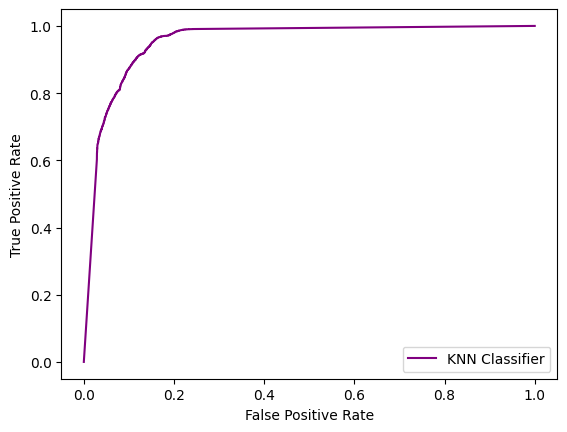

In [9]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

# Load the dataset
data = df_80

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)


# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)




params_grid = {'weights': 'distance', 'n_neighbors': 5, 'leaf_size': 50, 'algorithm': 'ball_tree'}
# Define the model

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier(**params_grid)
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)


print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# show the plot
pyplot.show()




KNN test roc-auc: 0.9511231840222283
Confusion Matrix :  [[8561 1291]
 [ 892 9256]]
Precision Score :  0.8775955247937802
Recall Score :  0.9121009065825778
Accuracy Score :  0.89085
F1 Score :  0.8945155834742692
Time Taken to train and test :  1113.1393642425537


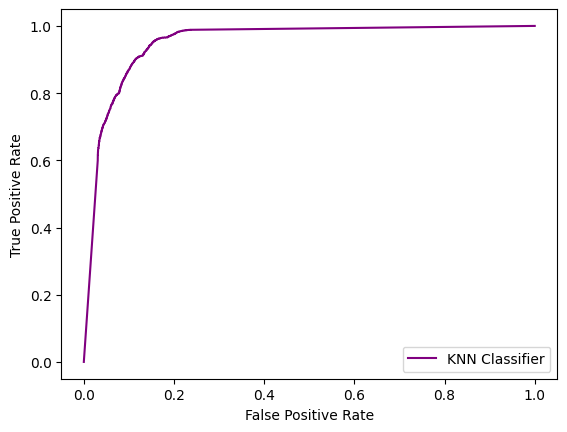

In [10]:
# Checking on the other 20% of dataset

X_test = df_20.iloc[:, 1:]
y_test = df_20.iloc[:, 0]

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)

ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)


print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# show the plot
pyplot.show()

# Perform Hyper parameter tunning

In [13]:
# import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
data = df_80

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)


# define the KNN classifier
knn = KNeighborsClassifier()

# define the hyperparameters and their respective ranges
param_dist = {'n_neighbors': [5, 10, 15],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'leaf_size': [30, 40, 50]}

# perform the RandomizedSearchCV
grid_search = GridSearchCV(knn, param_grid=param_dist, n_jobs=-1)
grid_search.fit(X_train, y_train)

# print the best hyperparameters and the accuracy score
print('Best Hyperparameters:', grid_search.best_params_)
print('Accuracy Score:', grid_search.score(X_test, y_test))


Best Hyperparameters: {'algorithm': 'auto', 'leaf_size': 30, 'n_neighbors': 5, 'weights': 'distance'}
Accuracy Score: 0.8927326902681683


# Using the hyper parameter obtained to train the model and predict

Started...
KNN train roc-auc: 1.0
KNN test roc-auc: 0.953591442806494
Confusion Matrix :  [[8559 1322]
 [ 802 9118]]
Precision Score :  0.8733716475095785
Recall Score :  0.9191532258064516
Accuracy Score :  0.8927326902681683
F1 Score :  0.8956777996070727
Time Taken to train and test :  6.845727920532227


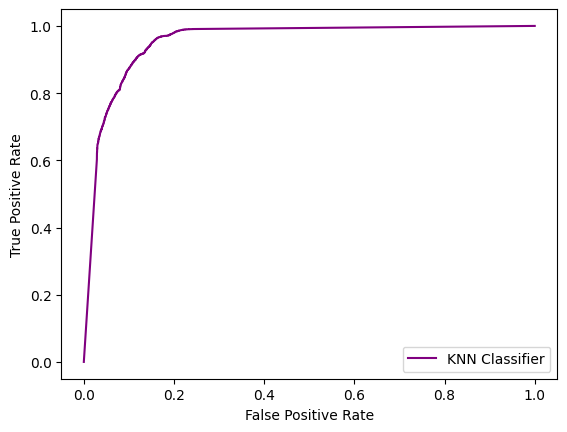

In [14]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

# Load the dataset
data = df_80

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)


# Noramalization of dataset -- May prevent overfitting.
min_max_scaler = MinMaxScaler()

# For the training dataset, we perform fit_transform.
X_train = min_max_scaler.fit_transform(X_train)

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)




params_grid = {'algorithm': 'auto', 'leaf_size': 30, 'n_neighbors': 5, 'weights': 'distance'}
# Define the model

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier(**params_grid)
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)


print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# show the plot
pyplot.show()




# Checking on the other 20% dataset

KNN test roc-auc: 0.9511231840222283
Confusion Matrix :  [[8561 1291]
 [ 892 9256]]
Precision Score :  0.8775955247937802
Recall Score :  0.9121009065825778
Accuracy Score :  0.89085
F1 Score :  0.8945155834742692
Time Taken to train and test :  62.07176494598389


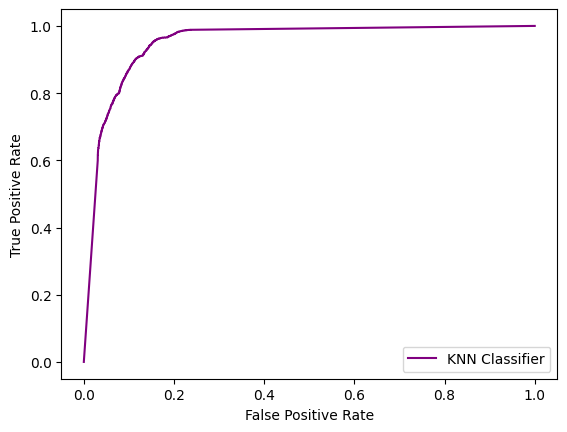

In [15]:
# Checking on the other 20% of dataset

X_test = df_20.iloc[:, 1:]
y_test = df_20.iloc[:, 0]

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)

ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)


print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# show the plot
pyplot.show()

KNN test roc-auc: 0.9511231840222283
Confusion Matrix :  [[9083  769]
 [2029 8119]]
Precision Score :  0.9134788478847885
Recall Score :  0.8000591249507292
Accuracy Score :  0.8601
F1 Score :  0.8530153393570078
Time Taken to train and test :  688.9488670825958


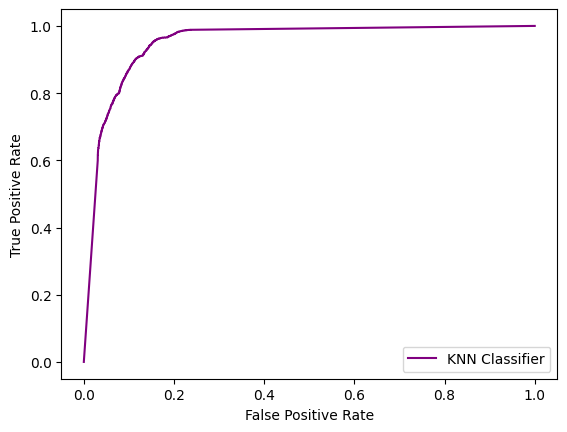

In [21]:
# Checking on the other 20% of dataset

X_test = df_20.iloc[:, 1:]
y_test = df_20.iloc[:, 0]

# For test data we transform based on fitting on training data
X_test = min_max_scaler.transform(X_test)

ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
y_pred = (ytest_pred[:, 1] > 0.7).astype(int)
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix

knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)


print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()

# show the plot
pyplot.show()

In [3]:
import pandas as pd
import seaborn as sns

# Load your data from CSV file
df = pd.read_csv("final_dataframe_complete_experiment.csv", header=None)

df = df.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import tensorflow as tf

# Load dataset
data = df_80k.iloc[:, 1:].to_numpy()
target = df_80k.iloc[:, 0].to_numpy()

# Reshape data into 3D format
data = data.reshape(-1, 85, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.25, random_state=42)

# Define CNN model
model = Sequential()
model.add(Conv1D(32, 3, activation='relu', input_shape=(85, 1), padding='same'))
model.add(Conv1D(64, 3, activation='relu', padding='same'))
model.add(Conv1D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10


2023-03-25 11:11:45.856892: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1857/1857 [==============================] - ETA: 0s - loss: 0.6710 - accuracy: 0.5062

2023-03-25 11:12:00.802425: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1857/1857 [==============================] - 18s 9ms/step - loss: 0.6710 - accuracy: 0.5062 - val_loss: 0.3952 - val_accuracy: 0.5028
Epoch 2/10
1857/1857 [==============================] - 17s 9ms/step - loss: 0.3854 - accuracy: 0.5062 - val_loss: 0.3765 - val_accuracy: 0.5028
Epoch 3/10
1857/1857 [==============================] - 17s 9ms/step - loss: 0.3702 - accuracy: 0.5062 - val_loss: 0.3783 - val_accuracy: 0.5028
Epoch 4/10
1857/1857 [==============================] - 16s 9ms/step - loss: 0.3636 - accuracy: 0.5062 - val_loss: 0.3635 - val_accuracy: 0.5028
Epoch 5/10
1857/1857 [==============================] - 16s 9ms/step - loss: 0.3611 - accuracy: 0.5062 - val_loss: 0.3614 - val_accuracy: 0.5028
Epoch 6/10
1857/1857 [==============================] - 16s 9ms/step - loss: 0.3545 - accuracy: 0.5062 - val_loss: 0.3701 - val_accuracy: 0.5028
Epoch 7/10
1857/1857 [==============================] - 16s 9ms/step - loss: 0.3528 - accuracy: 0.5062 - val_loss: 0.3690 - val_accuracy: 0.5

In [19]:
target

array([[ 23,  56,  46, ...,  84,  67, 101],
       [ 29,  42,  39, ...,  61,  67,  72],
       [ 46,  47,   2, ...,  75,  84,  26],
       ...,
       [ 27,  60,  28, ...,  58,  90,  44],
       [170, 141, 146, ..., 263, 243, 254],
       [ 60,  21,  53, ...,  90, 108,  94]])

In [10]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 85, 64)            256       
                                                                 
 conv1d_5 (Conv1D)           (None, 85, 128)           24704     
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 42, 128)          0         
 1D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 5376)              0         
                                                                 
 dense_4 (Dense)             (None, 64)                344128    
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                      

In [35]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier


# Load the data
data = pd.read_csv('final_dataframe_complete_experiment.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model architecture
def create_model(optimizer='adam', activation='relu', dropout_rate=0.2, neurons=128):
    model = Sequential()
    model.add(Dense(neurons, input_dim=85, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(neurons, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Create the model using KerasClassifier for Scikit-learn compatibility
model = KerasClassifier(build_fn=create_model, verbose=0)

# Define the hyperparameters to be tuned
param_grid = {
    'batch_size': [16, 32, 64],
    'epochs': [50, 100, 150],
    'optimizer': ['adam', 'sgd'],
    'activation': ['relu', 'tanh'],
    'dropout_rate': [0.1, 0.2, 0.3],
    'neurons': [64, 128, 256]
}

# Use GridSearchCV to tune the hyperparameters
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Print the best hyperparameters and accuracy score
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

# Evaluate the model on the test set using the best hyperparameters
best_model = grid_result.best_estimator_
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


/var/folders/_w/n_8gf6lx5hg6605yqrhm6cnh0000gn/T/ipykernel_2516/531542544.py:41: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_model, verbose=0)


Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1
Metal device set to: Apple M1


2023-03-25 12:55:20.345149: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-25 12:55:20.345254: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-25 12:55:20.353489: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-25 12:55:20.358020: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL,

KeyboardInterrupt: 

In [30]:
import tensorflow as tf
import keras_tuner as kt


In [37]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
# Load the data
data = pd.read_csv('final_dataframe_complete_experiment.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create a pipeline that includes scaling and the neural network model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=1000, early_stopping=True))
])

# define the parameter grid to search over
param_grid = {
    'mlp__hidden_layer_sizes': [(50,50), (100,), (32,64,32), (128,128,128)],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__learning_rate_init': [0.001, 0.01, 0.05],
}

# create a grid search object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)


# perform the grid search
grid_search.fit(X_train, y_train)

# print the best parameters and score
print('Best parameters: ', grid_search.best_params_)
print('Best score: ', grid_search.best_score_)


Best parameters:  {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 128, 128), 'mlp__learning_rate_init': 0.001}
Best score:  0.6377351438922452


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_hyper_params = {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 128, 128), 'mlp__learning_rate_init': 0.001}

pipeline.set_params(**best_hyper_params)

pipeline.fit(X_train, y_train)

yprob_pred = pipeline.predict_proba(X_test)




# print("Accuracy Score : ", accuracy_score(y_test, y_pred))
# print("Precision Score : ", precision_score(y_test, y_pred))
# print("Recall Score : ", recall_score(y_test, y_pred))
# print("F1 Score : ", f1_score(y_test, y_pred))

AttributeError: 'MLPRegressor' object has no attribute 'predict_proba'

## Hidden Layer Size (128, 128, 128)

In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
# Load the data
data = pd.read_csv('final_dataframe_complete_experiment.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


best_hyper_params = {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 128, 128), 'learning_rate_init': 0.001}


# create a pipeline that includes scaling and the neural network model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=1000, early_stopping=True, **best_hyper_params))
])

In [7]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=(128, 128, 128),
                              max_iter=1000))])

In [9]:
yprob_pred = pipeline.predict(X_test)

In [32]:
y_pred = (yprob_pred > 0.5).astype(int)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))

Accuracy Score :  0.8880752477747617
Precision Score :  0.8604020781567653
Recall Score :  0.9341508277130595
F1 Score :  0.8957610676700569


In [35]:
X_test2 = df_20k.iloc[:, 1:]
y_test2 = df_20k.iloc[:, 0]

In [36]:
yprob_pred = pipeline.predict(X_test2)
y_pred2 = (yprob_pred > 0.5).astype(int)

print("Accuracy Score : ", accuracy_score(y_test2, y_pred2))
print("Precision Score : ", precision_score(y_test2, y_pred2))
print("Recall Score : ", recall_score(y_test2, y_pred2))
print("F1 Score : ", f1_score(y_test2, y_pred2))

Accuracy Score :  0.89225
Precision Score :  0.8617671195404395
Recall Score :  0.9366699702675917
F1 Score :  0.897658735812319


## 128, 128, 128, 128

In [1]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf

# Load the data
data = pd.read_csv('final_dataframe_complete_experiment.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(85,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(1, activation='softmax')
])


# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model.fit(X_test, y_test, epochs=10, batch_size=16, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)


Metal device set to: Apple M1
Epoch 1/10


2023-03-26 13:55:51.073445: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-26 13:55:51.073556: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-26 13:55:51.204919: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


  1/792 [..............................] - ETA: 4:16 - loss: 0.0000e+00 - accuracy: 0.5625

2023-03-26 13:55:51.379658: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


786/792 [============================>.] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.5013

2023-03-26 13:55:57.449981: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


792/792 [==============================] - 7s 9ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 2/10
792/792 [==============================] - 7s 9ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 3/10
792/792 [==============================] - 7s 9ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 4/10
792/792 [==============================] - 7s 9ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 5/10
792/792 [==============================] - 7s 9ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 6/10
792/792 [==============================] - 7s 8ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_loss: 0.0000e+00 - val_accuracy: 0.4926
Epoch 7/10
792/792 [==============================] - 7s 8ms/step - loss: 0.0000e+00 - accuracy: 0.5013 - val_l

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

yprob_pred = pipeline.predict(X_test)
y_pred = (yprob_pred > 0.4).astype(int)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))

Accuracy Score :  0.5113944826715485
Precision Score :  0.5113944826715485
Recall Score :  1.0
F1 Score :  0.6767187369476234


In [51]:

X_test2 = df_20k.iloc[:, 1:]
y_test2 = df_20k.iloc[:, 0]

yprob_pred = pipeline.predict(X_test2)
y_pred2 = (yprob_pred > 0.5).astype(int)

print("Accuracy Score : ", accuracy_score(y_test2, y_pred2))
print("Precision Score : ", precision_score(y_test2, y_pred2))
print("Recall Score : ", recall_score(y_test2, y_pred2))
print("F1 Score : ", f1_score(y_test2, y_pred2))

Accuracy Score :  0.889
Precision Score :  0.8525827573663151
Recall Score :  0.9399438540204532
F1 Score :  0.894134477825465


In [60]:
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the data
data = pd.read_csv('final_dataframe_complete_experiment.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


best_hyper_params = {'solver': 'adam', 'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 128, 128,64), 'learning_rate_init': 0.001}


model = MLPClassifier(**best_hyper_params, max_iter=1000)

model.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(64, 128, 128, 64), max_iter=1000)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

yprob_pred = pipeline.predict(X_test)
y_pred = (yprob_pred > 0.4).astype(int)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))

Accuracy Score :  0.5113944826715485
Precision Score :  0.5113944826715485
Recall Score :  1.0
F1 Score :  0.6767187369476234


In [1]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf

# Load the data
data = pd.read_csv('20k_dataframe_2303.csv', header=None)
df = data.sample(frac=1).reset_index(drop=True)

df_20k = df.iloc[:20000, :]
df_80k = df.iloc[20000:, :]

X = df_80k.iloc[:, 1:].values
y = df_80k.iloc[:, 0].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(85,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(1, activation='softmax')
])


# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model.fit(X_test, y_test, epochs=10, batch_size=16, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)


Metal device set to: Apple M1
Epoch 1/10


2023-03-27 11:58:10.821695: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 11:58:10.822321: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-27 11:58:10.997674: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1/2 [==============>...............] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.4375

2023-03-27 11:58:11.184178: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 1s 537ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 2/10
2/2 [==============================] - 0s 30ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 3/10


2023-03-27 11:58:11.749002: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 0s 29ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 4/10
2/2 [==============================] - 0s 29ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 5/10
2/2 [==============================] - 0s 28ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 6/10
2/2 [==============================] - 0s 28ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 7/10
2/2 [==============================] - 0s 28ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 8/10
2/2 [==============================] - 0s 28ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 9/10
2/2 [==============================] - 0s 30ms/step - loss: 0.0000e+00 - accuracy: 0.4286 - val_loss: 0.0000e+00 - val

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(128, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1


2023-03-27 18:08:49.362023: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 18:08:49.362709: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2023-03-27 18:08:49.604808: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 18:08:49.826913: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 24.0177 - accuracy: 0.7184

2023-03-27 18:08:53.629885: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 5s 9ms/step - loss: 24.0177 - accuracy: 0.7184 - val_loss: 6.4448 - val_accuracy: 0.8265
Epoch 2/50
472/472 [==============================] - 4s 8ms/step - loss: 8.2164 - accuracy: 0.7845 - val_loss: 3.9016 - val_accuracy: 0.8192
Epoch 3/50
472/472 [==============================] - 4s 8ms/step - loss: 5.6430 - accuracy: 0.8022 - val_loss: 3.0321 - val_accuracy: 0.8063
Epoch 4/50
472/472 [==============================] - 4s 8ms/step - loss: 4.7373 - accuracy: 0.8033 - val_loss: 2.6721 - val_accuracy: 0.8051
Epoch 5/50
472/472 [==============================] - 4s 8ms/step - loss: 3.7221 - accuracy: 0.8106 - val_loss: 2.0288 - val_accuracy: 0.8589
Epoch 6/50
472/472 [==============================] - 4s 8ms/step - loss: 3.3162 - accuracy: 0.8148 - val_loss: 1.9168 - val_accuracy: 0.8087
Epoch 7/50
472/472 [==============================] - 4s 8ms/step - loss: 2.8968 - accuracy: 0.8202 - val_loss: 1.4256 - val_accuracy: 0.8496
Epoch 8/50
472/4

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(128, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1


2023-03-27 18:49:18.355508: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 18:49:18.355604: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2023-03-27 18:49:18.572365: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 18:49:18.778347: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 2.7335 - accuracy: 0.7454

2023-03-27 18:49:22.806780: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 5s 9ms/step - loss: 2.7335 - accuracy: 0.7454 - val_loss: 0.4318 - val_accuracy: 0.8452
Epoch 2/50
472/472 [==============================] - 4s 8ms/step - loss: 0.4678 - accuracy: 0.8088 - val_loss: 0.3522 - val_accuracy: 0.8502
Epoch 3/50
472/472 [==============================] - 4s 9ms/step - loss: 0.4158 - accuracy: 0.8223 - val_loss: 0.3397 - val_accuracy: 0.8494
Epoch 4/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3701 - accuracy: 0.8379 - val_loss: 0.3202 - val_accuracy: 0.8609
Epoch 5/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3286 - accuracy: 0.8563 - val_loss: 0.3200 - val_accuracy: 0.8740
Epoch 6/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3198 - accuracy: 0.8692 - val_loss: 0.2837 - val_accuracy: 0.8864
Epoch 7/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3037 - accuracy: 0.8733 - val_loss: 0.2693 - val_accuracy: 0.8875
Epoch 8/50
472/47

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(128, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1


2023-03-27 19:35:01.346930: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 19:35:01.347196: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2023-03-27 19:35:01.615992: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 19:35:01.825101: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 5.7235 - accuracy: 0.7557

2023-03-27 19:35:05.554687: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 5s 9ms/step - loss: 5.7235 - accuracy: 0.7557 - val_loss: 0.8555 - val_accuracy: 0.8667
Epoch 2/50
472/472 [==============================] - 4s 9ms/step - loss: 0.7536 - accuracy: 0.8026 - val_loss: 0.3927 - val_accuracy: 0.8029
Epoch 3/50
472/472 [==============================] - 4s 9ms/step - loss: 0.4433 - accuracy: 0.8333 - val_loss: 0.3598 - val_accuracy: 0.8621
Epoch 4/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3685 - accuracy: 0.8557 - val_loss: 0.2956 - val_accuracy: 0.8860
Epoch 5/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3408 - accuracy: 0.8652 - val_loss: 0.2984 - val_accuracy: 0.8875
Epoch 6/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3271 - accuracy: 0.8695 - val_loss: 0.3055 - val_accuracy: 0.8794
Epoch 7/50
472/472 [==============================] - 4s 9ms/step - loss: 0.3152 - accuracy: 0.8732 - val_loss: 0.2913 - val_accuracy: 0.8879
Epoch 8/50
472/47

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(128, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=45, batch_size=16, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1


2023-03-27 19:53:29.776140: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 19:53:29.776789: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/45


2023-03-27 19:53:30.005464: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 19:53:30.233238: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - ETA: 0s - loss: 3.6877 - accuracy: 0.7735

2023-03-27 19:53:37.574704: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - 9s 9ms/step - loss: 3.6877 - accuracy: 0.7735 - val_loss: 0.4407 - val_accuracy: 0.7898
Epoch 2/45
944/944 [==============================] - 8s 8ms/step - loss: 0.5674 - accuracy: 0.8187 - val_loss: 0.3182 - val_accuracy: 0.8778
Epoch 3/45
944/944 [==============================] - 8s 8ms/step - loss: 0.4215 - accuracy: 0.8426 - val_loss: 0.3242 - val_accuracy: 0.8772
Epoch 4/45
944/944 [==============================] - 8s 8ms/step - loss: 0.3616 - accuracy: 0.8563 - val_loss: 0.2759 - val_accuracy: 0.8854
Epoch 5/45
944/944 [==============================] - 8s 8ms/step - loss: 0.3474 - accuracy: 0.8596 - val_loss: 0.3082 - val_accuracy: 0.8828
Epoch 6/45
944/944 [==============================] - 8s 8ms/step - loss: 0.3428 - accuracy: 0.8659 - val_loss: 0.3092 - val_accuracy: 0.8788
Epoch 7/45
944/944 [==============================] - 8s 8ms/step - loss: 0.3122 - accuracy: 0.8750 - val_loss: 0.4697 - val_accuracy: 0.8156
Epoch 8/45
944/94

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(64, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=45, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1
Epoch 1/45


2023-03-27 20:08:31.837798: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 20:08:31.837886: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-27 20:08:32.024130: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 20:08:32.221810: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 5.7241 - accuracy: 0.7562

2023-03-27 20:08:35.922918: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 4s 9ms/step - loss: 5.7241 - accuracy: 0.7562 - val_loss: 1.4857 - val_accuracy: 0.7260
Epoch 2/45
472/472 [==============================] - 4s 8ms/step - loss: 1.1289 - accuracy: 0.7921 - val_loss: 0.3958 - val_accuracy: 0.8474
Epoch 3/45
472/472 [==============================] - 4s 8ms/step - loss: 0.6149 - accuracy: 0.8168 - val_loss: 0.4697 - val_accuracy: 0.7703
Epoch 4/45
472/472 [==============================] - 4s 8ms/step - loss: 0.5064 - accuracy: 0.8270 - val_loss: 0.3378 - val_accuracy: 0.8472
Epoch 5/45
472/472 [==============================] - 4s 8ms/step - loss: 0.4257 - accuracy: 0.8434 - val_loss: 0.3103 - val_accuracy: 0.8834
Epoch 6/45
472/472 [==============================] - 4s 8ms/step - loss: 0.3751 - accuracy: 0.8523 - val_loss: 0.3021 - val_accuracy: 0.8758
Epoch 7/45
472/472 [==============================] - 4s 8ms/step - loss: 0.3469 - accuracy: 0.8593 - val_loss: 0.3026 - val_accuracy: 0.8782
Epoch 8/45
472/47

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(64, activation='relu', input_shape=(85,)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=45, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Epoch 1/45
  7/472 [..............................] - ETA: 4s - loss: 103.8844 - accuracy: 0.5938  

2023-03-27 20:13:00.635888: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 10.6866 - accuracy: 0.7798

2023-03-27 20:13:04.054267: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 4s 8ms/step - loss: 10.6866 - accuracy: 0.7798 - val_loss: 1.8636 - val_accuracy: 0.8548
Epoch 2/45
472/472 [==============================] - 4s 8ms/step - loss: 1.7726 - accuracy: 0.7900 - val_loss: 0.7016 - val_accuracy: 0.8510
Epoch 3/45
472/472 [==============================] - 4s 8ms/step - loss: 0.9869 - accuracy: 0.7989 - val_loss: 0.4422 - val_accuracy: 0.8138
Epoch 4/45
472/472 [==============================] - 4s 8ms/step - loss: 0.6547 - accuracy: 0.8106 - val_loss: 0.3969 - val_accuracy: 0.8647
Epoch 5/45
472/472 [==============================] - 4s 8ms/step - loss: 0.5276 - accuracy: 0.8213 - val_loss: 0.3508 - val_accuracy: 0.8683
Epoch 6/45
472/472 [==============================] - 4s 8ms/step - loss: 0.4656 - accuracy: 0.8316 - val_loss: 0.6254 - val_accuracy: 0.8426
Epoch 7/45
472/472 [==============================] - 4s 8ms/step - loss: 0.4279 - accuracy: 0.8355 - val_loss: 0.4871 - val_accuracy: 0.7449
Epoch 8/45
472/4

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to the model
model.add(Dense(100, activation='relu', input_shape=(85,)))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=45, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Epoch 1/45
  1/472 [..............................] - ETA: 2:41 - loss: 430.6666 - accuracy: 0.4062

2023-03-27 20:16:46.557970: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 7.1446 - accuracy: 0.7977

2023-03-27 20:16:50.066291: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 4s 9ms/step - loss: 7.1446 - accuracy: 0.7977 - val_loss: 1.2364 - val_accuracy: 0.8395
Epoch 2/45
472/472 [==============================] - 4s 8ms/step - loss: 1.4616 - accuracy: 0.8238 - val_loss: 0.6622 - val_accuracy: 0.8643
Epoch 3/45
472/472 [==============================] - 4s 8ms/step - loss: 0.8809 - accuracy: 0.8324 - val_loss: 0.4770 - val_accuracy: 0.8583
Epoch 4/45
472/472 [==============================] - 4s 8ms/step - loss: 0.6723 - accuracy: 0.8342 - val_loss: 0.4934 - val_accuracy: 0.8339
Epoch 5/45
472/472 [==============================] - 4s 8ms/step - loss: 0.5108 - accuracy: 0.8485 - val_loss: 0.4693 - val_accuracy: 0.8850
Epoch 6/45
472/472 [==============================] - 4s 8ms/step - loss: 0.4363 - accuracy: 0.8532 - val_loss: 0.3627 - val_accuracy: 0.8653
Epoch 7/45
472/472 [==============================] - 4s 8ms/step - loss: 0.4009 - accuracy: 0.8577 - val_loss: 0.3819 - val_accuracy: 0.8198
Epoch 8/45
472/47

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to t model
model.add(Dense(100, activation='relu', input_shape=(85,)))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1
Epoch 1/50


2023-03-27 20:28:51.823973: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 20:28:51.824057: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-27 20:28:52.003568: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


  1/472 [..............................] - ETA: 2:48 - loss: 211.5951 - accuracy: 0.5938

2023-03-27 20:28:52.178842: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 6.4573 - accuracy: 0.7945

2023-03-27 20:28:55.677493: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 4s 8ms/step - loss: 6.4573 - accuracy: 0.7945 - val_loss: 1.2899 - val_accuracy: 0.8206
Epoch 2/50
472/472 [==============================] - 4s 8ms/step - loss: 1.3655 - accuracy: 0.8170 - val_loss: 1.1672 - val_accuracy: 0.7489
Epoch 3/50
472/472 [==============================] - 4s 8ms/step - loss: 0.8040 - accuracy: 0.8302 - val_loss: 0.5061 - val_accuracy: 0.8506
Epoch 4/50
472/472 [==============================] - 4s 8ms/step - loss: 0.5821 - accuracy: 0.8408 - val_loss: 0.4179 - val_accuracy: 0.8760
Epoch 5/50
472/472 [==============================] - 4s 8ms/step - loss: 0.4870 - accuracy: 0.8443 - val_loss: 0.3639 - val_accuracy: 0.8903
Epoch 6/50
472/472 [==============================] - 4s 8ms/step - loss: 0.4154 - accuracy: 0.8547 - val_loss: 0.3310 - val_accuracy: 0.8840
Epoch 7/50
472/472 [==============================] - 4s 8ms/step - loss: 0.3914 - accuracy: 0.8648 - val_loss: 0.3565 - val_accuracy: 0.8883
Epoch 8/50
472/47

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# create a Sequential model
model = Sequential()

# add layers to t model
model.add(Dense(100, activation='relu', input_shape=(85,)))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Epoch 1/100
  1/472 [..............................] - ETA: 2:37 - loss: 258.5820 - accuracy: 0.6250

2023-03-27 20:32:20.376265: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - ETA: 0s - loss: 6.4925 - accuracy: 0.7878

2023-03-27 20:32:23.849082: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


472/472 [==============================] - 4s 8ms/step - loss: 6.4925 - accuracy: 0.7878 - val_loss: 1.3278 - val_accuracy: 0.8029
Epoch 2/100
472/472 [==============================] - 4s 8ms/step - loss: 1.3596 - accuracy: 0.8247 - val_loss: 0.7143 - val_accuracy: 0.8798
Epoch 3/100
472/472 [==============================] - 4s 8ms/step - loss: 0.8889 - accuracy: 0.8311 - val_loss: 0.4735 - val_accuracy: 0.8337
Epoch 4/100
472/472 [==============================] - 4s 8ms/step - loss: 0.6400 - accuracy: 0.8432 - val_loss: 0.4293 - val_accuracy: 0.8428
Epoch 5/100
472/472 [==============================] - 4s 8ms/step - loss: 0.5141 - accuracy: 0.8461 - val_loss: 0.3571 - val_accuracy: 0.8846
Epoch 6/100
472/472 [==============================] - 4s 8ms/step - loss: 0.4115 - accuracy: 0.8573 - val_loss: 0.3727 - val_accuracy: 0.8871
Epoch 7/100
472/472 [==============================] - 4s 8ms/step - loss: 0.3750 - accuracy: 0.8621 - val_loss: 0.3014 - val_accuracy: 0.8834
Epoch 8/100

In [1]:
 import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=42)


# create a Sequential model
model = Sequential()

# add layers to t model
model.add(Dense(100, activation='relu', input_shape=(85,)))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1


2023-03-27 21:04:25.410265: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 21:04:25.410353: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2023-03-27 21:04:25.616940: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-27 21:04:25.789096: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - ETA: 0s - loss: 5.6153 - accuracy: 0.7941

2023-03-27 21:04:32.385864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - 7s 7ms/step - loss: 5.6153 - accuracy: 0.7941 - val_loss: 0.8469 - val_accuracy: 0.8093
Epoch 2/100
944/944 [==============================] - 7s 7ms/step - loss: 0.7204 - accuracy: 0.8319 - val_loss: 0.3676 - val_accuracy: 0.8769
Epoch 3/100
944/944 [==============================] - 7s 7ms/step - loss: 0.4962 - accuracy: 0.8428 - val_loss: 0.4135 - val_accuracy: 0.8213
Epoch 4/100
944/944 [==============================] - 6s 7ms/step - loss: 0.3990 - accuracy: 0.8539 - val_loss: 0.2718 - val_accuracy: 0.8788
Epoch 5/100
944/944 [==============================] - 6s 7ms/step - loss: 0.3562 - accuracy: 0.8634 - val_loss: 0.3630 - val_accuracy: 0.8163
Epoch 6/100
944/944 [==============================] - 6s 7ms/step - loss: 0.3356 - accuracy: 0.8659 - val_loss: 0.2717 - val_accuracy: 0.8878
Epoch 7/100
944/944 [==============================] - 6s 7ms/step - loss: 0.3105 - accuracy: 0.8718 - val_loss: 0.2835 - val_accuracy: 0.8928
Epoch 8/100

In [1]:
 import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd

# load the data
df = pd.read_csv('20k_dataframe_2303.csv', header=None)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(set(y))

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.2, random_state=42)


# create a Sequential model
model = Sequential()

# add layers to t model
model.add(Dense(100, activation='relu', input_shape=(85,)))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# train the model on the training set
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val))

# evaluate the model on the testing set
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)


{0, 1}
Metal device set to: Apple M1
Epoch 1/100


2023-03-27 21:23:53.818700: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-27 21:23:53.818798: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-27 21:23:53.999093: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


  1/944 [..............................] - ETA: 5:48 - loss: 123.9587 - accuracy: 0.5625

2023-03-27 21:23:54.179589: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - ETA: 0s - loss: 8.0305 - accuracy: 0.7792

2023-03-27 21:24:00.771072: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


944/944 [==============================] - 7s 7ms/step - loss: 8.0305 - accuracy: 0.7792 - val_loss: 3.0701 - val_accuracy: 0.8054
Epoch 2/100
944/944 [==============================] - 7s 7ms/step - loss: 3.4130 - accuracy: 0.8229 - val_loss: 2.1732 - val_accuracy: 0.8123
Epoch 3/100
944/944 [==============================] - 7s 7ms/step - loss: 2.4293 - accuracy: 0.8252 - val_loss: 2.2253 - val_accuracy: 0.7686
Epoch 4/100
944/944 [==============================] - 7s 7ms/step - loss: 1.9082 - accuracy: 0.8350 - val_loss: 1.5810 - val_accuracy: 0.7925
Epoch 5/100
944/944 [==============================] - 7s 7ms/step - loss: 1.5153 - accuracy: 0.8401 - val_loss: 0.8683 - val_accuracy: 0.8520
Epoch 6/100
944/944 [==============================] - 6s 7ms/step - loss: 1.2274 - accuracy: 0.8435 - val_loss: 0.6237 - val_accuracy: 0.8818
Epoch 7/100
944/944 [==============================] - 7s 7ms/step - loss: 1.0459 - accuracy: 0.8436 - val_loss: 0.7747 - val_accuracy: 0.8769
Epoch 8/100